# NASA Near-Earth Asteroid Risk Classification and Clustering
## Machine Learning Project 2
**Team:** Darian Dean

### Project Goals
This project classifies and analyzes NASA near-Earth asteroids (NEAs) and close approach events using both **supervised** and **unsupervised** machine learning:
- **Binary classification** - predict whether an asteroid is Potentially Hazardous (PHA)
- **Clustering** - discover natural groupings in orbital and physical properties
- **Dimensionality reduction** - PCA for visualization and feature compression

---
### Table of Contents
1. Imports & Setup  
2. Data Loading & Exploration  
3. Data Preprocessing  
4. Exploratory Data Analysis (EDA)  
5. Supervised Learning - Benchmarking (Logistic Regression baseline)  
6. Supervised Learning - Tuning & RBF Expansion  
7. Dimensionality Reduction (PCA)  
8. Unsupervised Learning (K-Means Clustering)  
9. Results Summary

---
## 1. Imports & Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Sklearn preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# Sklearn supervised
from sklearn.linear_model import LogisticRegression

# Sklearn unsupervised
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Sklearn evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    silhouette_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

seed = 10
np.random.seed(seed)

# Plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 11,
})
PALETTE = ['#2563EB', '#DC2626', '#16A34A', '#EA580C', '#7C3AED', '#0891B2']
sns.set_palette(PALETTE)

---
## 2. Data Loading & Exploration

In [ ]:
# Load datasets
nea = pd.read_csv('near_earth_asteroids_2025 (1).csv', low_memory =False)
ca = pd.read_csv('asteroid_close_approaches_2015_2035 (1).csv')

print('='*61)
print(f'Near-Earth Asteroids (NEA) dataset : {nea.shape[0]:,} rows x {nea.shape[1]} columns')
print(f'Close Approaches (CA) dataset      : {ca.shape[0]:,} rows x {ca.shape[1]} columns')
print('='*61)

Near-Earth Asteroids (NEA) dataset : 18,523 rows x 29 columns
Close Approaches (CA) dataset      : 27,430 rows x 13 columns


In [ ]:
# Preview NEA dataset
print('NEA Dataset Preview')
nea.head()

NEA Dataset Preview


,spkid,full_name,pdes,name,pha,H,diameter_km,diameter_m,diameter_is_estimated,size_category,...,per_y,moid_au,moid_km,moid_lunar_distances,n,condition_code,first_obs,last_obs,data_arc,data_arc_years
0,20000433,433 Eros (A898 PA),433,Eros,False,10.39,16.84000,16840.0,False,Large (>1 km) — City killer+,...,1.76,0.1480,22140485.0,57.60,0.5598,0.0,1893-10-29,2021-05-13,46582.0,127.53
1,20000719,719 Albert (A911 TB),719,Albert,False,15.59,2.70683,2706.8,True,Large (>1 km) — City killer+,...,4.28,0.2010,30069172.0,78.22,0.2302,0.0,1911-10-04,2026-03-20,41806.0,114.46
2,20000887,887 Alinda (A918 AA),887,Alinda,False,13.82,4.20000,4200.0,False,Large (>1 km) — City killer+,...,3.89,0.0797,11922950.0,31.02,0.2533,0.0,1918-02-09,2025-08-27,39281.0,107.55
3,20001036,1036 Ganymed (A924 UB),1036,Ganymed,False,9.17,37.67500,37675.0,False,Large (>1 km) — City killer+,...,4.35,0.3430,51312070.0,133.49,0.2266,0.0,1924-10-23,2026-03-22,37040.0,101.41
4,20001221,1221 Amor (1932 EA1),1221,Amor,False,17.37,1.00000,1000.0,False,Large (>1 km) — City killer+,...,2.66,0.1080,16156570.0,42.03,0.3705,0.0,1932-03-12,2025-02-19,33947.0,92.94


In [ ]:
# Preview Close Approaches dataset
print('Close Approaches Dataset Preview')
ca.head()

Close Approaches Dataset Preview


,designation,full_name,close_approach_date,distance_au,dist_km,dist_lunar,distance_min_au,distance_max_au,velocity_km_s,v_rel_kmh,velocity_infinity_km_s,absolute_magnitude,is_future
0,2022 AP1,(2022 AP1),2015-01-01 00:27,0.045100,6746806.0,17.55,0.013778,0.076571,11.891749,42810.0,11.886780,28.39,False
1,2015 AE45,(2015 AE45),2015-01-02 15:56,0.048239,7216474.0,18.77,0.048220,0.048258,7.065686,25436.0,7.057864,25.30,False
2,613286,613286 (2005 YQ96),2015-01-02 21:46,0.026522,3967664.0,10.32,0.026522,0.026522,12.703378,45732.0,12.695467,20.63,False
3,2014 YQ34,(2014 YQ34),2015-01-03 13:29,0.079692,11921722.0,31.01,0.078275,0.081108,24.982094,89936.0,24.980756,24.16,False
4,2014 YE42,(2014 YE42),2015-01-03 15:00,0.010995,1644896.0,4.28,0.010971,0.011020,13.998882,50396.0,13.981561,23.40,False


In [ ]:
# Column info for NEA
print('NEA Column Info')
nea.info()

NEA Column Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18523 entries, 0 to 18522
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   spkid                  18523 non-null  int64  
 1   full_name              18522 non-null  object 
 2   pdes                   18522 non-null  object 
 3   name                   182 non-null    object 
 4   pha                    18522 non-null  object 
 5   H                      18520 non-null  float64
 6   diameter_km            18522 non-null  float64
 7   diameter_m             18522 non-null  float64
 8   diameter_is_estimated  18522 non-null  object 
 9   size_category          18522 non-null  object 
 10  albedo                 1204 non-null   float64
 11  rot_per                1928 non-null   float64
 12  class                  18522 non-null  object 
 13  e                      18522 non-null  float64
 14  a                      18522 non-null 

In [ ]:
# Basic statistics
print('NEA Descriptive Statistics ')
nea.describe()

NEA Descriptive Statistics 


,spkid,H,diameter_km,diameter_m,albedo,rot_per,e,a,i,q,ad,per,per_y,moid_au,moid_km,moid_lunar_distances,n,condition_code,data_arc,data_arc_years
count,1.852300e+04,18520.000000,18522.000000,18522.000000,1204.000000,1928.000000,18522.000000,18522.000000,18522.000000,18522.000000,18522.000000,1.852200e+04,18522.000000,1.840200e+04,1.840200e+04,18402.000000,18522.000000,18521.000000,18355.000000,18355.000000
mean,7.675325e+06,22.555617,0.275259,275.254087,0.172680,18.422669,0.447345,1.801705,12.789841,0.915493,2.687914,1.059019e+03,2.900078,9.901889e-02,1.481302e+07,38.535155,0.514190,3.949031,2796.578970,7.656594
std,8.551810e+06,3.012456,0.570932,570.934120,0.144368,74.556970,0.176062,2.802185,11.239946,0.237341,5.587585,1.803300e+04,49.481675,1.047633e-01,1.567237e+07,40.770712,0.279307,3.618407,4098.443836,11.220922
min,3.824900e+04,9.170000,0.000475,0.500000,0.009000,0.003298,0.004000,0.555300,0.020000,0.070000,0.650000,1.510000e+02,0.414000,4.540000e-07,6.800000e+01,0.000000,0.000150,0.000000,0.000000,0.000000
25%,3.555202e+06,20.210000,0.038411,38.400000,0.047000,2.385500,0.319600,1.320000,4.710000,0.780000,1.730000,5.540000e+02,1.520000,1.740000e-02,2.603003e+06,6.770000,0.301400,0.000000,10.000000,0.030000
50%,3.723701e+06,22.590000,0.107761,107.800000,0.137000,4.914000,0.460700,1.728000,9.060000,0.965000,2.510000,8.300000e+02,2.270000,5.850000e-02,8.751475e+06,22.770000,0.433900,5.000000,84.000000,0.230000
75%,3.797856e+06,24.830000,0.323937,323.900000,0.256000,11.797300,0.571300,2.203000,18.217500,1.078000,3.410000,1.190000e+03,3.270000,1.540000e-01,2.303807e+07,59.930000,0.649875,7.000000,4912.000000,13.450000
max,5.457442e+07,34.370000,37.675000,37675.000000,0.856000,1880.000000,0.996400,350.300000,154.350000,1.300000,699.320000,2.390000e+06,6560.000000,7.080000e-01,1.059153e+08,275.530000,2.382000,9.000000,46582.000000,127.530000


In [ ]:
# Target class distribution
print('PHA (Target) Class Distribution')
vc = nea['pha'].value_counts()
print(vc)
print(f'\nClass imbalance ratio: {vc[False]:,} Non-PHA : {vc[True]:,} PHA  ({100*vc[True]/len(nea):.1f}% positive)')

PHA (Target) Class Distribution
pha
False    16615
True      1907
Name: count, dtype: int64

Class imbalance ratio: 16,615 Non-PHA : 1,907 PHA  (10.3% positive)


In [ ]:
# Missing value summary
print('Missing Values (% per column)')
miss = (nea.isnull().sum() / len(nea) * 100).sort_values(ascending = False)
print(miss[miss > 0].round(2).to_string())

Missing Values (% per column)
name                     99.02
albedo                   93.50
rot_per                  89.59
data_arc                  0.91
data_arc_years            0.91
moid_km                   0.65
moid_au                   0.65
moid_lunar_distances      0.65
H                         0.02
condition_code            0.01
pha                       0.01
diameter_is_estimated     0.01
pdes                      0.01
per_y                     0.01
class                     0.01
diameter_m                0.01
size_category             0.01
diameter_km               0.01
full_name                 0.01
i                         0.01
e                         0.01
a                         0.01
per                       0.01
ad                        0.01
q                         0.01
last_obs                  0.01
n                         0.01
first_obs                 0.01


---
## 3. Data Preprocessing

**Decisions:**
- Drop `albedo` (97% missing) and `rot_per` (95% missing) - too sparse to impute reliably.
- Select 9 informative orbital/physical features for modeling.
- Drop rows missing any selected feature (< 0.5% of data).
- Encode `pha` as integer (True --> 1, False -> 0).
- Standardize all features: zero mean, unit variance.
- 70/30 stratified train-test split.

In [ ]:
# Feature selection
FEATURES = [
    'H',          # Absolute magnitude (proxy for size)
    'e',          # Orbital eccentricity
    'a',          # Semi-major axis (AU)
    'i',          # Inclination (degrees)
    'q',          # Perihelion distance (AU)
    'ad',         # Aphelion distance (AU)
    'moid_au',    # Min. Orbit Intersection Distance (AU) - key PHA criterion
    'n',          # Mean motion (deg/day)
    'diameter_km' # Estimated diameter
]
TARGET = 'pha'

# Drop rows with missing values in selected features
df = nea[FEATURES + [TARGET]].dropna().copy()
df[TARGET] = df[TARGET].astype(int)

print(f'Rows after dropping missing: {len(df):,}  (dropped {len(nea)-len(df):,})')
print(f'Features: {FEATURES}')
print(f'Positive class (PHA=1): {df[TARGET].sum():,} ({100*df[TARGET].mean():.2f}%)')

Rows after dropping missing: 18,400  (dropped 123)
Features: ['H', 'e', 'a', 'i', 'q', 'ad', 'moid_au', 'n', 'diameter_km']
Positive class (PHA=1): 1,907 (10.36%)


In [ ]:
# Train/test split (stratified 70/30)
X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.30, stratify = y, random_state = 10
)

print(f'Train set: {X_train.shape[0]:,} samples  (PHA={y_train.sum():,}, {100*y_train.mean():.2f}%)')
print(f'Test  set: {X_test.shape[0]:,} samples  (PHA={y_test.sum():,}, {100*y_test.mean():.2f}%)')

Train set: 12,880 samples  (PHA=1,335, 10.36%)
Test  set: 5,520 samples  (PHA=572, 10.36%)


In [ ]:
# Standardize features
# Fit only on training data, then apply to both sets (avoid data leakage)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print('Standardized.')

Standardization applied.


---
## 4. Exploratory Data Analysis (EDA)

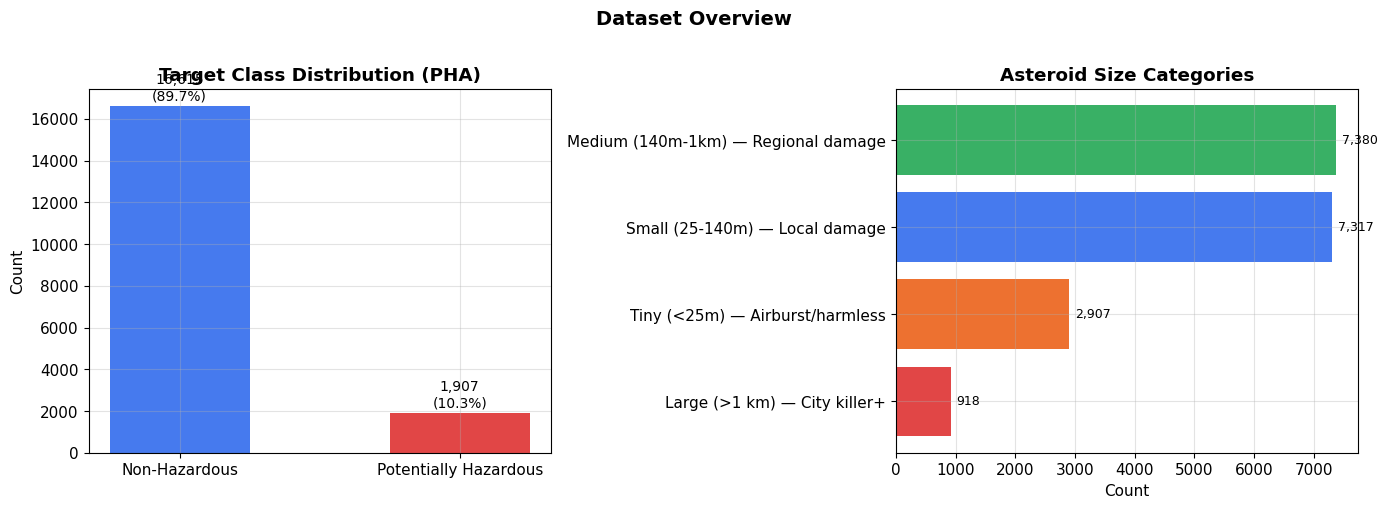

In [ ]:
# 4a: Class distribution & Size categories
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Class distribution
ax = axes[0]
counts = nea['pha'].value_counts()
bars = ax.bar(['Non-Hazardous', 'Potentially Hazardous'],
              [counts[False], counts[True]],
              color = ['#2563EB', '#DC2626'], alpha = 0.85, width = 0.5)
for b, v in zip(bars, [counts[False], counts[True]]):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 300,
            f'{v:,}\n({100*v/len(nea):.1f}%)', ha = 'center', fontsize = 10)
ax.set_title('Target Class Distribution (PHA)', fontweight = 'bold')
ax.set_ylabel('Count')

# Size categories
ax = axes[1]
sc = nea['size_category'].value_counts()
short = [s.split(' -')[0] for s in sc.index]
ax.barh(short[::-1], sc.values[::-1],
        color = ['#DC2626','#EA580C','#2563EB','#16A34A'], alpha = 0.85)
ax.set_title('Asteroid Size Categories', fontweight='bold')
ax.set_xlabel('Count')
for i, v in enumerate(sc.values[::-1]):
    ax.text(v + 100, i, f'{v:,}', va = 'center', fontsize = 9)

plt.suptitle('Dataset Overview', fontsize = 14, fontweight = 'bold', y = 1.01)
plt.tight_layout()
plt.show()

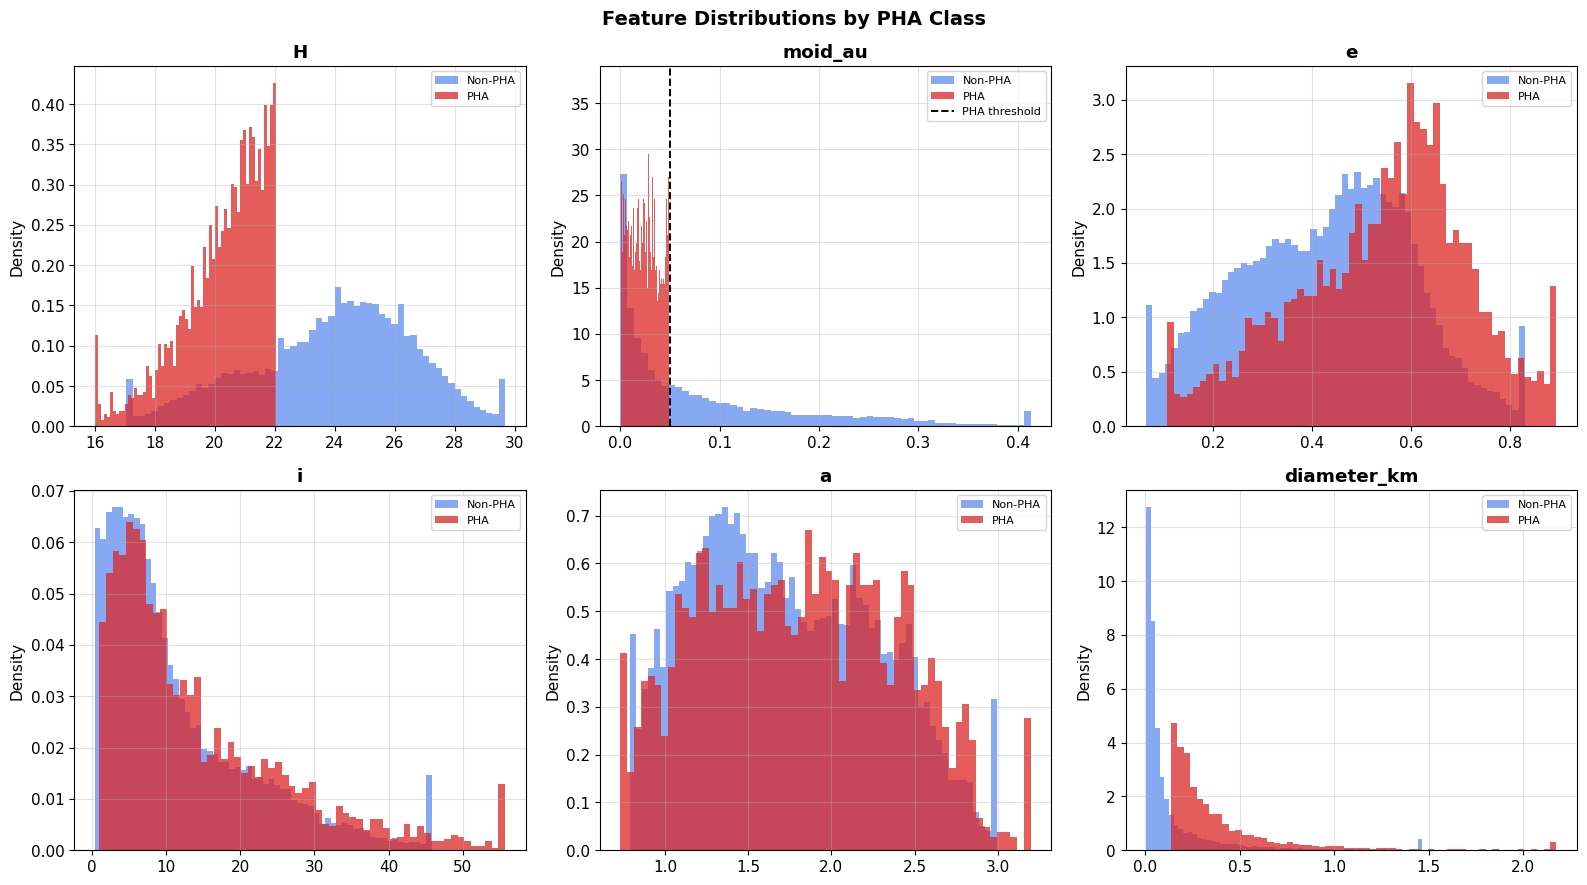

In [ ]:
# 4b: Feature distributions by PHA class
plot_feats = ['H', 'moid_au', 'e', 'i', 'a', 'diameter_km']
fig, axes = plt.subplots(2, 3, figsize = (16, 9))

for ax, feat in zip(axes.flat, plot_feats):
    safe = df[df[TARGET] == 0][feat]
    pha = df[df[TARGET] == 1][feat]
    ax.hist(safe.clip(*safe.quantile([0.01, 0.99])), bins = 60,
            color = '#2563EB', alpha = 0.55, density = True, label = 'Non-PHA')
    ax.hist(pha.clip(*pha.quantile([0.01, 0.99])),  bins = 60,
            color = '#DC2626', alpha = 0.75, density  = True, label = 'PHA')
    if feat == 'moid_au':
        ax.axvline(0.05, ls = '--', color = 'black', lw = 1.4, label = 'PHA threshold')
    ax.set_title(feat, fontweight = 'bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize = 8)

plt.suptitle('Feature Distributions by PHA Class', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

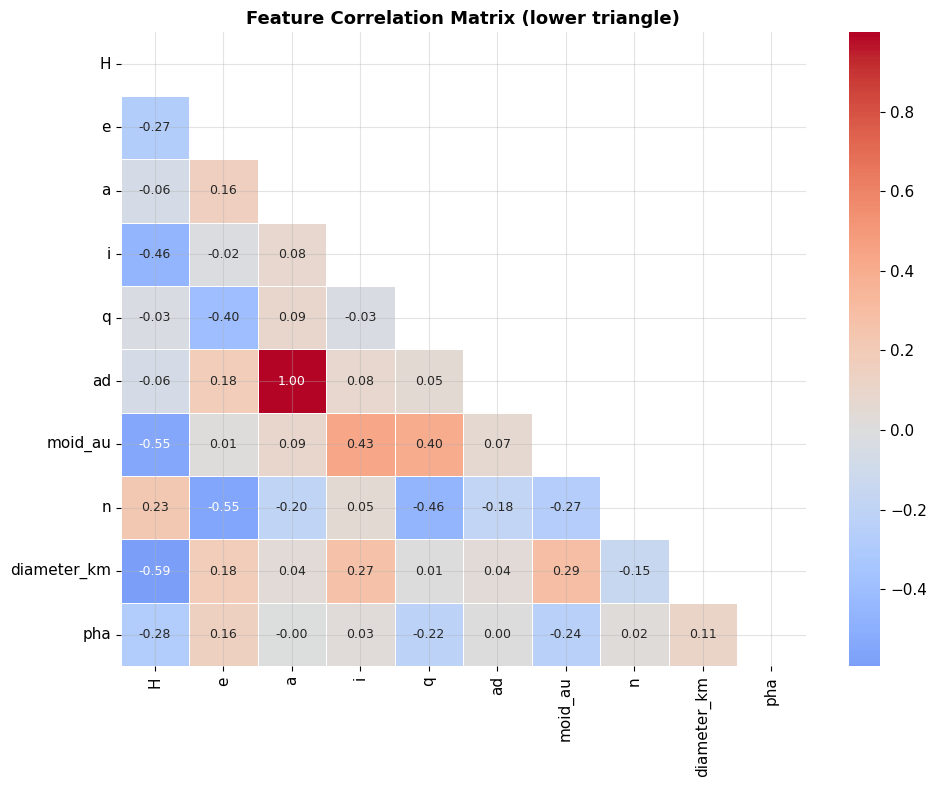

In [ ]:
# 4c: Correlation heatmap
fig, ax = plt.subplots(figsize = (10, 8))
corr = df[FEATURES + [TARGET]].corr()
mask = np.triu(np.ones_like(corr, dtype = bool))
sns.heatmap(corr, mask = mask, annot = True, fmt = '.2f', cmap = 'coolwarm',
            center = 0, linewidths = 0.5, ax = ax,
            annot_kws = {'size': 9})
ax.set_title('Feature Correlation Matrix (lower triangle)', fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.show()

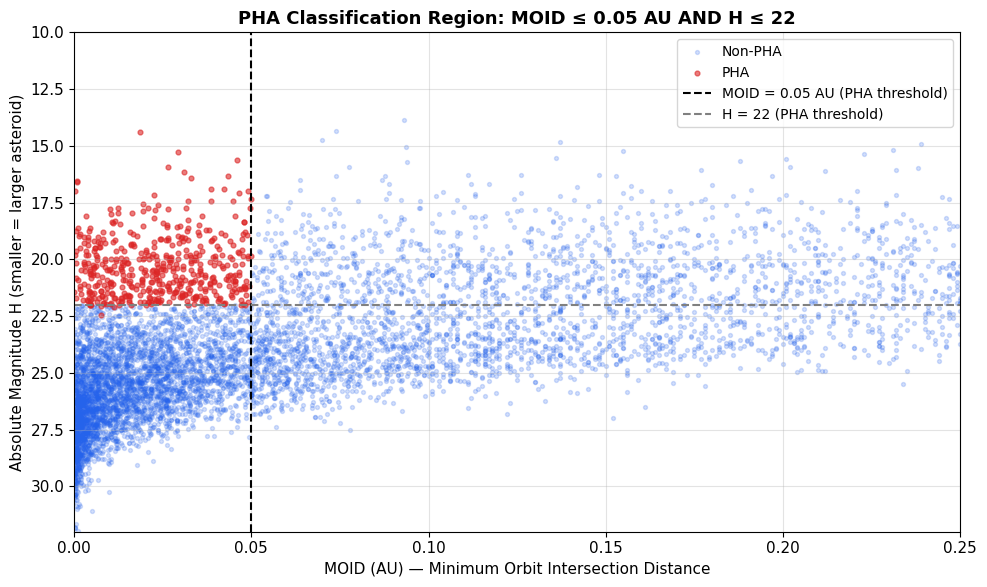

In [ ]:
# 4d: MOID vs H scatter (the two defining PHA criteria)
fig, ax = plt.subplots(figsize = (10, 6))
idx = np.random.choice(len(df), 8000, replace = False)
sub = df.iloc[idx]

ax.scatter(sub[sub[TARGET] == 0]['moid_au'], sub[sub[TARGET] == 0]['H'],
           c = '#2563EB', alpha = 0.2, s = 8, label = 'Non-PHA')
ax.scatter(sub[sub[TARGET] == 1]['moid_au'], sub[sub[TARGET] == 1]['H'],
           c = '#DC2626', alpha = 0.6, s = 12, label = 'PHA')

# PHA boundary lines
ax.axvline(0.05, color = 'black', ls = '--', lw = 1.5, label = 'MOID = 0.05 AU (PHA threshold)')
ax.axhline(22, color = 'gray',  ls = '--', lw = 1.5, label = 'H = 22 (PHA threshold)')
ax.set_xlim(0, 0.25)
ax.set_ylim(10, 32)
ax.set_xlabel('MOID (AU) - Minimum Orbit Intersection Distance', fontsize = 11)
ax.set_ylabel('Absolute Magnitude H (smaller = larger asteroid)', fontsize = 11)
ax.set_title('PHA Classification Region: MOID ≤ 0.05 AU AND H ≤ 22', fontsize = 13, fontweight = 'bold')
ax.legend(fontsize = 10)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

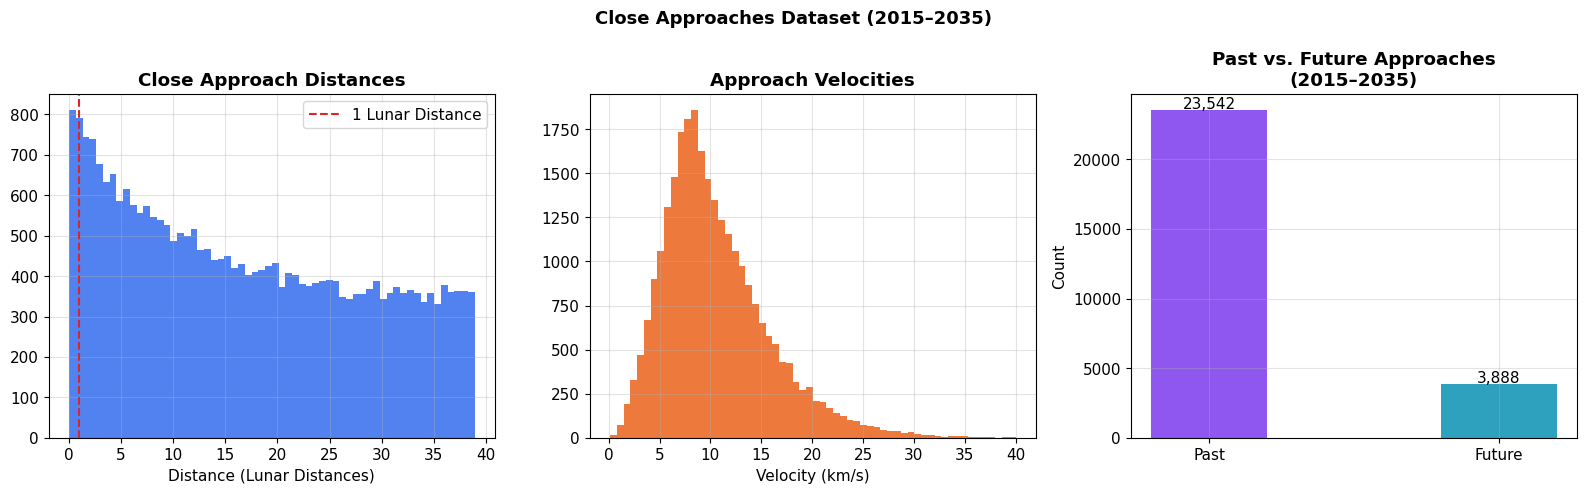

In [ ]:
# 4e: Close Approaches dataset - distance & velocity distribution
fig, axes = plt.subplots(1, 3, figsize = (16, 5))

ca_past = ca[ca['is_future'] == False]
ca_future = ca[ca['is_future'] == True]

ax = axes[0]
ax.hist(ca['dist_lunar'].dropna().clip(0, 100), bins = 60,
        color = '#2563EB', alpha = 0.8)
ax.axvline(1, color = '#DC2626', ls = '--', lw = 1.5, label = '1 Lunar Distance')
ax.set_xlabel('Distance (Lunar Distances)')
ax.set_title('Close Approach Distances', fontweight = 'bold')
ax.legend()

ax = axes[1]
ax.hist(ca['velocity_km_s'].dropna().clip(0, 40), bins = 60,
        color = '#EA580C', alpha = 0.8)
ax.set_xlabel('Velocity (km/s)')
ax.set_title('Approach Velocities', fontweight = 'bold')

ax = axes[2]
ax.bar(['Past', 'Future'],
       [len(ca_past), len(ca_future)],
       color = ['#7C3AED', '#0891B2'], alpha = 0.85, width = 0.4)
ax.set_title('Past vs. Future Approaches\n(2015–2035)', fontweight = 'bold')
ax.set_ylabel('Count')
for i, v in enumerate([len(ca_past), len(ca_future)]):
    ax.text(i, v + 80, f'{v:,}', ha = 'center')

plt.suptitle('Close Approaches Dataset (2015–2035)', fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.show()

---
## 5. Supervised Learning - Benchmarking

**Method:** Logistic Regression implemented via gradient descent in matrix form (scikit-learn's `lbfgs` solver is gradient-descent based). Default regularization `C=1`, no hyperparameter tuning. This is the **performance benchmark** all other models must beat.

**Evaluation metrics:** Accuracy, Precision, Recall, F1-score, AUC-ROC, Confusion Matrix.

In [ ]:
# Helper: evaluate a fitted classifier
def evaluate(name, clf, X_tr, X_te, y_tr, y_te, fit = True):
    """Fit (optional), predict, and return a results dict."""
    if fit:
        clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    y_prob = clf.predict_proba(X_te)[:,1] if hasattr(clf, 'predict_proba') else None

    metrics = dict(
        name   = name,
        clf    = clf,
        acc    = accuracy_score(y_te, y_pred),
        prec   = precision_score(y_te, y_pred, zero_division = 0),
        rec    = recall_score(y_te, y_pred, zero_division = 0),
        f1     = f1_score(y_te, y_pred, zero_division = 0),
        auc    = roc_auc_score(y_te, y_prob) if y_prob is not None else None,
        cm     = confusion_matrix(y_te, y_pred),
        y_pred = y_pred,
        y_prob = y_prob,
    )

    print(f"\n{'─'*55}")
    print(f"  Model   : {name}")
    print(f"  Accuracy : {metrics['acc']:.4f}")
    print(f"  Precision: {metrics['prec']:.4f}")
    print(f"  Recall   : {metrics['rec']:.4f}")
    print(f"  F1 Score : {metrics['f1']:.4f}")
    if metrics['auc']:
        print(f"  AUC-ROC  : {metrics['auc']:.4f}")
    return metrics

In [ ]:
# Baseline: Logistic Regression (C = 1, default)
base_lr = LogisticRegression(max_iter = 1000, random_state = seed)
r_base = evaluate('Baseline LR (C=1)', base_lr,
                   X_train_s, X_test_s, y_train, y_test)

print(f"\nFull Classification Report")
print(classification_report(y_test, r_base['y_pred'],
                            target_names = ['Non-PHA', 'PHA']))


───────────────────────────────────────────────────────
  Model   : Baseline LR (C=1)
  Accuracy : 0.9772
  Precision: 0.8361
  Recall   : 0.7835
  F1 Score : 0.8089
  AUC-ROC  : 0.9916

--- Full Classification Report ---
              precision    recall  f1-score   support

     Non-PHA       0.99      0.99      0.99     11583
         PHA       0.84      0.78      0.81       762

    accuracy                           0.98     12345
   macro avg       0.91      0.89      0.90     12345
weighted avg       0.98      0.98      0.98     12345



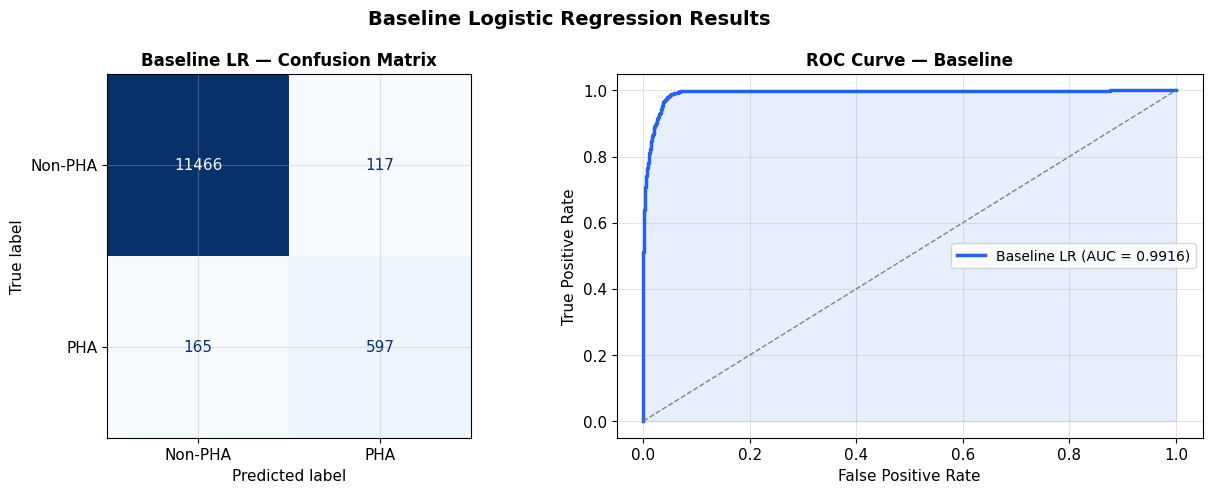

In [ ]:
# Baseline: Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize = (13, 5))

# Confusion matrix
ax = axes[0]
ConfusionMatrixDisplay(r_base['cm'], display_labels = ['Non-PHA', 'PHA']).plot(
    ax = ax, cmap = 'Blues', colorbar = False)
ax.set_title('Baseline LR - Confusion Matrix', fontweight = 'bold', fontsize = 12)

# ROC curve
ax = axes[1]
fpr, tpr, _ = roc_curve(y_test, r_base['y_prob'])
ax.plot(fpr, tpr, color = '#2563EB', lw = 2.5,
        label = f"Baseline LR (AUC = {r_base['auc']:.4f})")
ax.plot([0,1],[0,1],'--', color = 'gray', lw = 1)
ax.fill_between(fpr, tpr, alpha = 0.1, color = '#2563EB')
ax.set_xlabel('False Positive Rate', fontsize = 11)
ax.set_ylabel('True Positive Rate', fontsize = 11)
ax.set_title('ROC Curve - Baseline', fontweight = 'bold', fontsize = 12)
ax.legend(fontsize = 10)

plt.suptitle('Baseline Logistic Regression Results', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

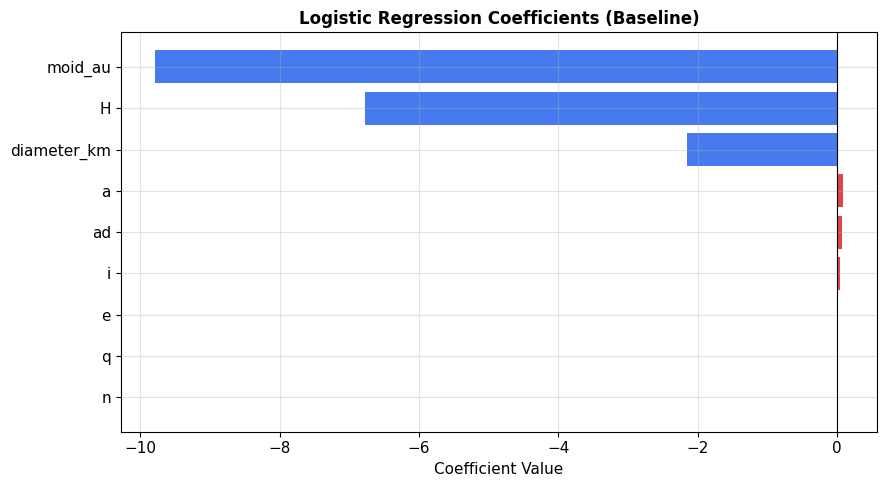

In [ ]:
# Baseline: Feature coefficients
coefs = base_lr.coef_[0]
sorted_idx = np.argsort(np.abs(coefs))[::-1]

fig, ax = plt.subplots(figsize = (9, 5))
colors_bar = ['#DC2626' if c > 0 else '#2563EB' for c in coefs[sorted_idx]]
ax.barh([FEATURES[i] for i in sorted_idx][::-1],
        coefs[sorted_idx][::-1], color = colors_bar[::-1], alpha = 0.85)
ax.axvline(0, color = 'black', lw = 0.8)
ax.set_xlabel('Coefficient Value', fontsize = 11)
ax.set_title('Logistic Regression Coefficients (Baseline)', fontsize = 12, fontweight = 'bold')
plt.tight_layout()
plt.show()

---
## 6. Supervised Learning - Tuning & RBF Expansion

### 6.1 Hyperparameter Tuning - Regularization Strength C

We search over C ∈ {0.001, 0.01, 0.1, 1, 10, 100} using 5-fold stratified cross-validation with **F1** as the scoring metric (appropriate for imbalanced classes).

In [ ]:
# C search via 5-fold stratified CV
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
cv_means, cv_stds = [], []

skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = seed)

for C in C_values:
    lr = LogisticRegression(C = C, max_iter = 2000, random_state = seed)
    scores = cross_val_score(lr, X_train_s, y_train,
                             cv = skf, scoring = 'f1', n_jobs = -1)
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())
    print(f'  C={C:<8}  CV F1 = {scores.mean():.4f} ± {scores.std():.4f}')

best_C = C_values[np.argmax(cv_means)]
print(f'\n>>> Best C = {best_C}  (CV F1 = {max(cv_means):.4f})')

  C=0.001     CV F1 = 0.0327 ± 0.0131
  C=0.01      CV F1 = 0.5534 ± 0.0321
  C=0.1       CV F1 = 0.7792 ± 0.0101
  C=1         CV F1 = 0.8026 ± 0.0083
  C=10        CV F1 = 0.8049 ± 0.0095
  C=100       CV F1 = 0.8051 ± 0.0095

>>> Best C = 100  (CV F1 = 0.8051)


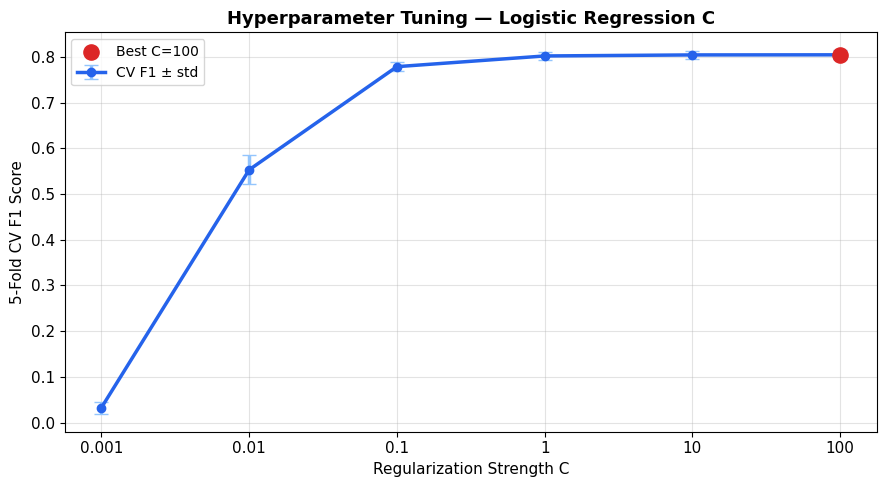

In [ ]:
# Plot CV F1 vs C
fig, ax = plt.subplots(figsize = (9, 5))
ax.errorbar(range(len(C_values)), cv_means, yerr = cv_stds,
            fmt = 'o-', color = '#2563EB', lw = 2.5, capsize = 5,
            ecolor = '#93C5FD', label = 'CV F1 ± std')
best_idx = np.argmax(cv_means)
ax.scatter([best_idx], [cv_means[best_idx]], color = '#DC2626', s = 120, zorder = 5,
           label = f'Best C={best_C}')
ax.set_xticks(range(len(C_values)))
ax.set_xticklabels([str(c) for c in C_values])
ax.set_xlabel('Regularization Strength C', fontsize = 11)
ax.set_ylabel('5-Fold CV F1 Score', fontsize = 11)
ax.set_title('Hyperparameter Tuning - Logistic Regression C', fontsize = 13, fontweight = 'bold')
ax.legend(fontsize = 10)
plt.tight_layout()
plt.show()

In [ ]:
# Tuned Logistic Regression
tuned_lr = LogisticRegression(C = best_C, max_iter = 2000, random_state = seed)
r_tuned = evaluate(f'Tuned LR (C={best_C})', tuned_lr,
                    X_train_s, X_test_s, y_train, y_test)


───────────────────────────────────────────────────────
  Model   : Tuned LR (C=100)
  Accuracy : 0.9772
  Precision: 0.8279
  Recall   : 0.7953
  F1 Score : 0.8112
  AUC-ROC  : 0.9916


### 6.2 RBF Kernel Expansion + Logistic Regression

Radial Basis Function expansion projects each input vector into a higher-dimensional space using random centers sampled from the training set:

$$\phi_k(\mathbf{x}) = \exp\left(-\gamma \|\mathbf{x} - \mathbf{c}_k\|^2\right), \quad \gamma = \frac{1}{d}$$

This allows logistic regression to learn **nonlinear decision boundaries** in the original feature space.

In [ ]:
# RBF Expansion
N_CENTERS = 50
rng = np.random.RandomState(seed)
center_idx = rng.choice(len(X_train_s), N_CENTERS, replace = False)
centers = X_train_s[center_idx]
gamma = 1.0 / X_train_s.shape[1]   # 1/d heuristic

def rbf_expand(X, ctrs, g):
    """Map X to RBF feature space using given centers and gamma."""
    # shape: (n_samples, n_centers)
    dists_sq = np.sum((X[:, np.newaxis, :] - ctrs[np.newaxis, :, :])**2, axis = 2)
    return np.exp(-g * dists_sq)

X_train_rbf = rbf_expand(X_train_s, centers, gamma)
X_test_rbf = rbf_expand(X_test_s, centers, gamma)

print(f'RBF-expanded feature shape - train: {X_train_rbf.shape}  test: {X_test_rbf.shape}')
print(f'(Original: {X_train_s.shape}  -->  Expanded: {X_train_rbf.shape})')

RBF-expanded feature shape — train: (28803, 50)  test: (12345, 50)
(Original: (28803, 9)  →  Expanded: (28803, 50))


In [ ]:
# RBF + LR: also tune C
rbf_cv_means = []
for C in C_values:
    lr = LogisticRegression(C = C, max_iter = 2000, random_state = seed)
    scores = cross_val_score(lr, X_train_rbf, y_train,
                             cv = skf, scoring = 'f1', n_jobs = -1)
    rbf_cv_means.append(scores.mean())
    print(f'  C={C:<8}  CV F1 = {scores.mean():.4f}')

best_C_rbf = C_values[np.argmax(rbf_cv_means)]
print(f'\n>>> Best C for RBF model = {best_C_rbf}  (CV F1 = {max(rbf_cv_means):.4f})')

  C=0.001     CV F1 = 0.0000
  C=0.01      CV F1 = 0.0000
  C=0.1       CV F1 = 0.4898
  C=1         CV F1 = 0.7484
  C=10        CV F1 = 0.8288
  C=100       CV F1 = 0.8472

>>> Best C for RBF model = 100  (CV F1 = 0.8472)


In [ ]:
# Evaluate RBF + LR
rbf_lr = LogisticRegression(C = best_C_rbf, max_iter = 2000, random_state = seed)
r_rbf = evaluate(f'RBF Expansion + LR (C={best_C_rbf})', rbf_lr,
                  X_train_rbf, X_test_rbf, y_train, y_test)

print(f"\nFull Classification Report")
print(classification_report(y_test, r_rbf['y_pred'],
                            target_names = ['Non-PHA','PHA']))


───────────────────────────────────────────────────────
  Model   : RBF Expansion + LR (C=100)
  Accuracy : 0.9829
  Precision: 0.8811
  Recall   : 0.8360
  F1 Score : 0.8579
  AUC-ROC  : 0.9960

--- Full Classification Report ---
              precision    recall  f1-score   support

     Non-PHA       0.99      0.99      0.99     11583
         PHA       0.88      0.84      0.86       762

    accuracy                           0.98     12345
   macro avg       0.94      0.91      0.92     12345
weighted avg       0.98      0.98      0.98     12345



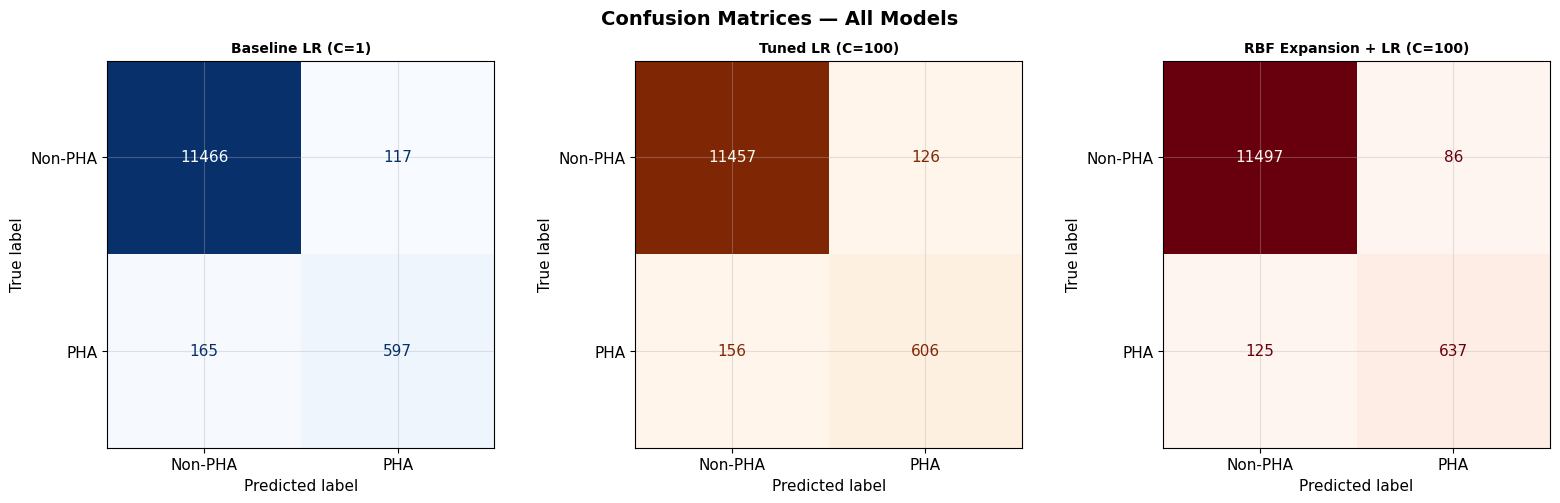

In [ ]:
# All models: confusion matrices side by side
all_results = [r_base, r_tuned, r_rbf]

fig, axes = plt.subplots(1, 3, figsize = (16, 5))
cmaps = ['Blues', 'Oranges', 'Reds']
for ax, r, cmap in zip(axes, all_results, cmaps):
    ConfusionMatrixDisplay(r['cm'], display_labels = ['Non-PHA','PHA']).plot(
        ax = ax, cmap = cmap, colorbar = False)
    ax.set_title(r['name'], fontweight = 'bold', fontsize = 10)

plt.suptitle('Confusion Matrices - All Models', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

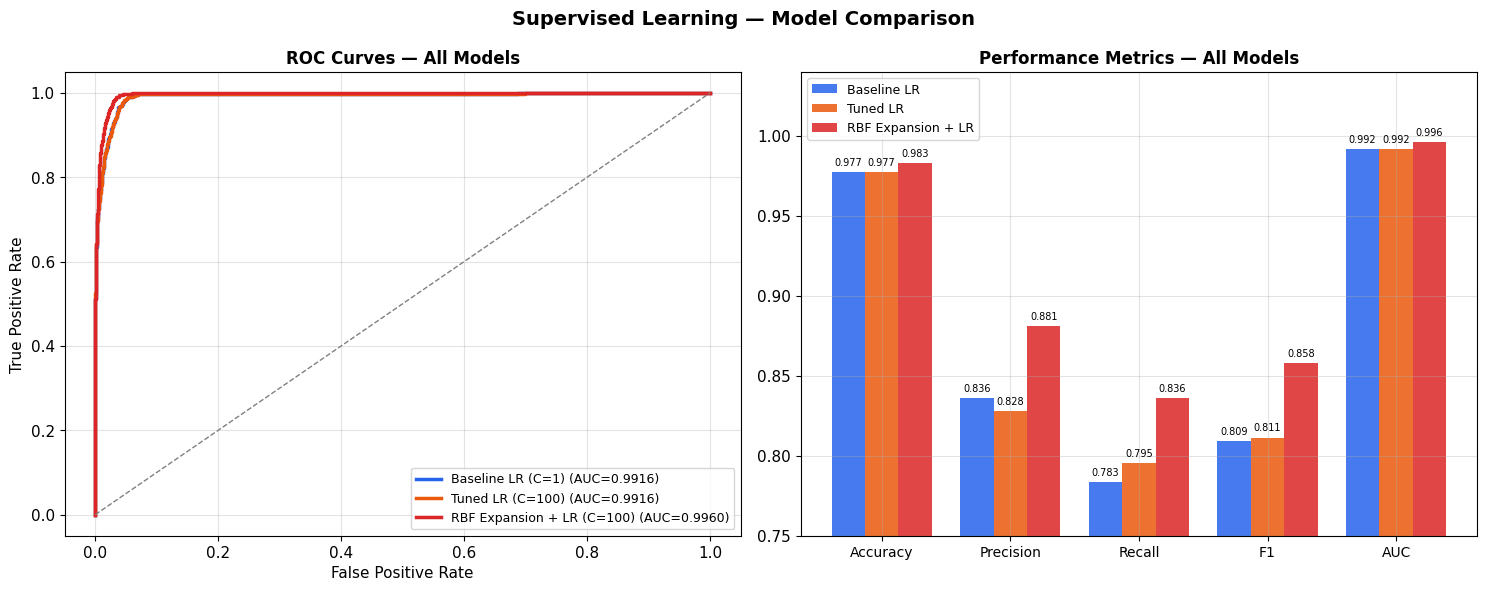

In [ ]:
# All models: ROC curves overlay
fig, axes = plt.subplots(1, 2, figsize = (15, 6))
colors_m = ['#2563EB', '#EA580C', '#DC2626']

ax = axes[0]
for r, c in zip(all_results, colors_m):
    if r['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
        ax.plot(fpr, tpr, color = c, lw = 2.5,
                label = f"{r['name']} (AUC={r['auc']:.4f})")
ax.plot([0,1],[0,1],'--', color = 'gray', lw = 1)
ax.set_xlabel('False Positive Rate', fontsize = 11)
ax.set_ylabel('True Positive Rate', fontsize = 11)
ax.set_title('ROC Curves - All Models', fontweight = 'bold', fontsize = 12)
ax.legend(fontsize = 9)

# Metric comparison bar chart
ax = axes[1]
metrics_compare = ['acc', 'prec', 'rec', 'f1', 'auc']
labels_compare = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
x = np.arange(len(metrics_compare))
w = 0.26

for i, (r, c) in enumerate(zip(all_results, colors_m)):
    vals = [r[m] for m in metrics_compare]
    bars = ax.bar(x + (i-1)*w, vals, w, label = r['name'].split('(')[0].strip(),
                  color = c, alpha = 0.85)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.003,
                f'{v:.3f}', ha = 'center', va = 'bottom', fontsize = 7)

ax.set_xticks(x)
ax.set_xticklabels(labels_compare, fontsize = 10)
ax.set_ylim(0.75, 1.04)
ax.set_title('Performance Metrics - All Models', fontweight = 'bold', fontsize = 12)
ax.legend(fontsize = 9)

plt.suptitle('Supervised Learning - Model Comparison', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

In [ ]:
# Summary table
summary = pd.DataFrame([
    {k: v for k,v in r.items() if k in ['name', 'acc', 'prec', 'rec', 'f1', 'auc']}
    for r in all_results
])
summary.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
summary = summary.set_index('Model')
print('\nSupervised Learning Results Summary')
summary.round(4)


--- Supervised Learning Results Summary ---


,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Baseline LR (C=1),0.9772,0.8361,0.7835,0.8089,0.9916
Tuned LR (C=100),0.9772,0.8279,0.7953,0.8112,0.9916
RBF Expansion + LR (C=100),0.9829,0.8811,0.8360,0.8579,0.9960


---
## 7. Dimensionality Reduction - PCA

PCA is applied to:
1. **Visualize** the feature space in 2D and understand class separability.
2. **Quantify** how many components are needed to retain 95% of variance.
3. **Pre-process** for clustering (reducing noise before K-Means).

In [ ]:
# Fit PCA on full standardized dataset
X_all_s = scaler.transform(df[FEATURES].values)
y_all = df[TARGET].values

pca_full = PCA(random_state = seed)
pca_full.fit(X_all_s)

evr = pca_full.explained_variance_ratio_
cum_var = np.cumsum(evr)
n_95 = np.searchsorted(cum_var, 0.95) + 1

print(f'Total components: {len(evr)}')
print(f'Components for 95% variance: {n_95}')
for i, (e, c) in enumerate(zip(evr, cum_var), 1):
    print(f'  PC{i}: {100*e:.2f}%  (cumulative: {100*c:.2f}%)')

Total components: 9
Components for 95% variance: 6
  PC1: 31.14%  (cumulative: 31.14%)
  PC2: 20.54%  (cumulative: 51.68%)
  PC3: 17.02%  (cumulative: 68.70%)
  PC4: 14.53%  (cumulative: 83.23%)
  PC5: 7.79%  (cumulative: 91.02%)
  PC6: 5.22%  (cumulative: 96.24%)
  PC7: 3.18%  (cumulative: 99.42%)
  PC8: 0.58%  (cumulative: 100.00%)
  PC9: 0.00%  (cumulative: 100.00%)


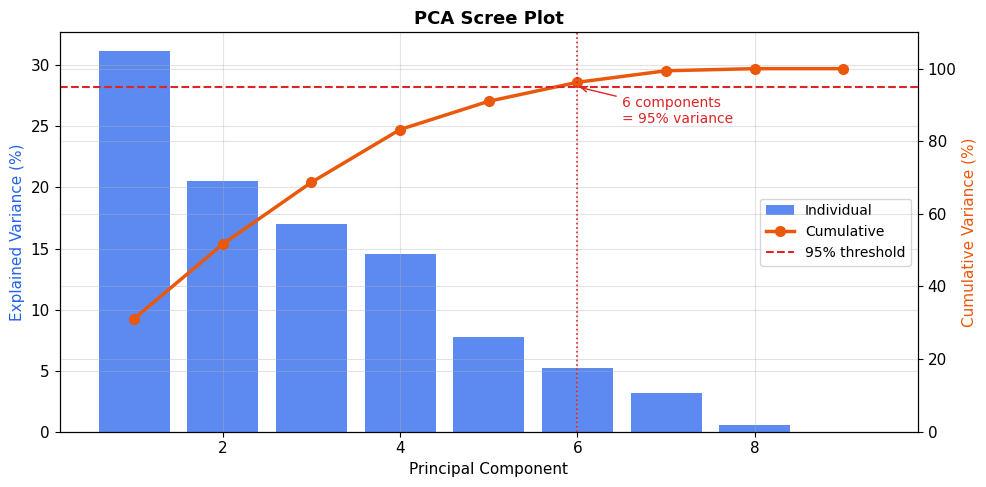

In [ ]:
# Scree plot
fig, ax = plt.subplots(figsize = (10, 5))
ax.bar(range(1, len(evr) + 1), evr * 100, color = '#2563EB', alpha = 0.75, label = 'Individual')
ax2 = ax.twinx()
ax2.plot(range(1, len(evr) + 1), cum_var * 100, 'o-', color = '#EA580C',
         lw = 2.5, ms = 7, label = 'Cumulative')
ax2.axhline(95, ls = '--', color = '#DC2626', lw = 1.5, label = '95% threshold')
ax2.axvline(n_95, ls = ':', color = '#DC2626', lw = 1.2)
ax2.annotate(f'{n_95} components\n= 95% variance',
             xy = (n_95, 95), xytext = (n_95 + 0.5, 85),
             arrowprops = dict(arrowstyle = '->', color = '#DC2626'),
             fontsize = 10, color = '#DC2626')
ax.set_xlabel('Principal Component', fontsize = 11)
ax.set_ylabel('Explained Variance (%)', fontsize = 11, color = '#2563EB')
ax2.set_ylabel('Cumulative Variance (%)', fontsize = 11, color = '#EA580C')
ax2.set_ylim(0, 110)
ax.set_title('PCA Scree Plot', fontsize =  13, fontweight = 'bold')
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, fontsize = 10, loc = 'center right')
plt.tight_layout()
plt.show()

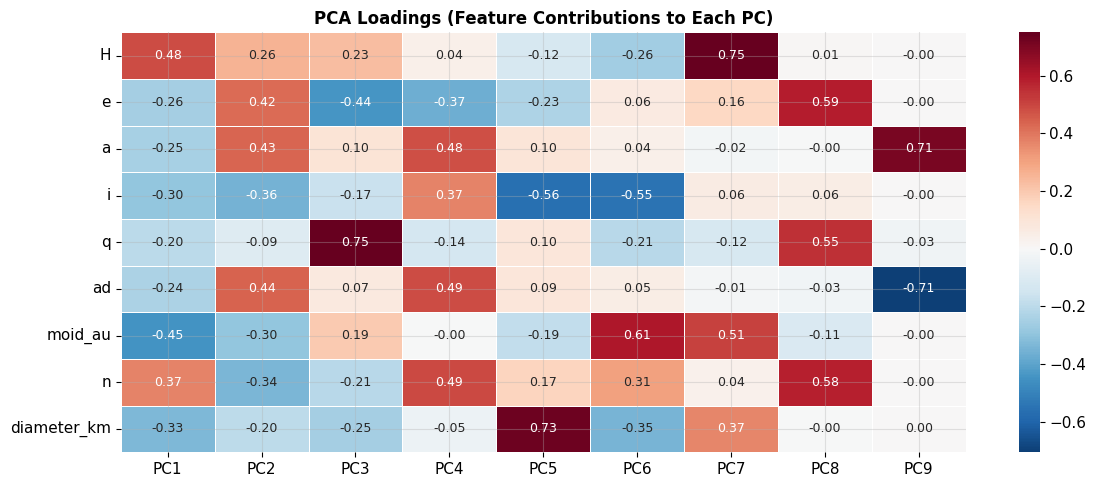

In [ ]:
# PCA loadings heatmap
loadings = pd.DataFrame(
    pca_full.components_.T,
    index = FEATURES,
    columns = [f'PC{i + 1}' for i in range(len(evr))]
)

fig, ax = plt.subplots(figsize = (12, 5))
sns.heatmap(loadings, annot = True, fmt = '.2f', cmap = 'RdBu_r',
            center = 0, linewidths = 0.4, ax = ax, annot_kws = {'size':9})
ax.set_title('PCA Loadings (Feature Contributions to Each PC)',
             fontsize = 12, fontweight = 'bold')
plt.tight_layout()
plt.show()

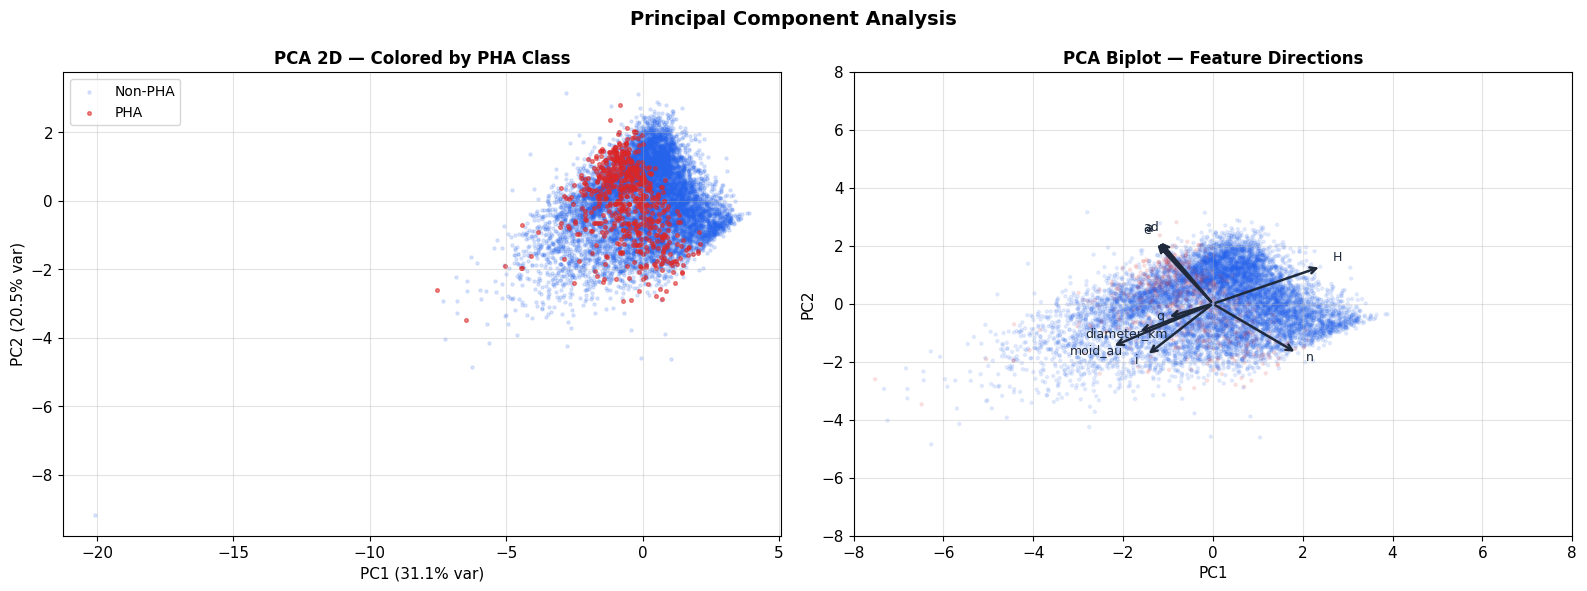

In [ ]:
# 2D PCA projection colored by PHA
pca2d = PCA(n_components = 2, random_state = seed)
X_2d = pca2d.fit_transform(X_all_s)

# Subsample for plot clarity
idx_plot = np.random.choice(len(X_2d), 10000, replace = False)

fig, axes = plt.subplots(1, 2, figsize = (16, 6))

# Colored by PHA label
ax = axes[0]
ax.scatter(X_2d[idx_plot][y_all[idx_plot] == 0, 0],
           X_2d[idx_plot][y_all[idx_plot] == 0, 1],
           c = '#2563EB', alpha = 0.15, s = 5, label = 'Non-PHA')
ax.scatter(X_2d[idx_plot][y_all[idx_plot] == 1, 0],
           X_2d[idx_plot][y_all[idx_plot] == 1, 1],
           c = '#DC2626', alpha = 0.55, s = 7, label = 'PHA')
ax.set_xlabel(f'PC1 ({100 * pca2d.explained_variance_ratio_[0]:.1f}% var)', fontsize = 11)
ax.set_ylabel(f'PC2 ({100 * pca2d.explained_variance_ratio_[1]:.1f}% var)', fontsize = 11)
ax.set_title('PCA 2D - Colored by PHA Class', fontweight = 'bold', fontsize = 12)
ax.legend(fontsize = 10)

# Biplot: feature vectors
ax = axes[1]
ax.scatter(X_2d[idx_plot, 0], X_2d[idx_plot, 1],
           c=[('#DC2626' if v else '#2563EB') for v in y_all[idx_plot]],
           alpha = 0.1, s = 5)
scale = 5
for i, feat in enumerate(FEATURES):
    ax.annotate('', xy = (pca_full.components_[0, i] * scale,
                        pca_full.components_[1, i] * scale),
                xytext = (0,0),
                arrowprops = dict(arrowstyle = '->', color = '#1E293B', lw = 1.8))
    ax.text(pca_full.components_[0, i] * scale * 1.15,
            pca_full.components_[1, i] * scale * 1.15,
            feat, fontsize = 9, color = '#1E293B', ha = 'center')
ax.set_xlim(-8, 8)
ax.set_ylim(-8, 8)
ax.set_xlabel('PC1', fontsize = 11)
ax.set_ylabel('PC2', fontsize = 11)
ax.set_title('PCA Biplot - Feature Directions', fontweight = 'bold', fontsize = 12)

plt.suptitle('Principal Component Analysis', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

---
## 8. Unsupervised Learning - K-Means Clustering

K-Means is applied to the standardized orbital feature matrix to discover **natural groupings**. We select optimal k using:
- **Elbow method** - inertia (within-cluster sum of squares) vs. k
- **Silhouette score** - measures cluster cohesion and separation (higher = better)

In [ ]:
# Elbow method & Silhouette score
K_RANGE = range(2, 11)
inertias = []
sil_scores = []

# Use PCA-compressed data (6 components, 95% variance) for clustering
pca_k = PCA(n_components = n_95, random_state = seed)
X_pca_k = pca_k.fit_transform(X_all_s)
print(f'Using {n_95}-component PCA projection for K-Means (95% variance retained).')

for k in K_RANGE:
    km = KMeans(n_clusters = k, random_state = seed, n_init = 10)
    labels = km.fit_predict(X_pca_k)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_pca_k, labels, sample_size = 5000, random_state = seed)
    sil_scores.append(sil)
    print(f'  k={k}  Inertia={km.inertia_:,.0f}  Silhouette={sil:.4f}')

best_k = list(K_RANGE)[np.argmax(sil_scores)]
print(f'\n>>> Best k = {best_k}  (Silhouette = {max(sil_scores):.4f})')

Using 6-component PCA projection for K-Means (95% variance retained).
  k=2  Inertia=268,665  Silhouette=0.2985
  k=3  Inertia=223,114  Silhouette=0.2931
  k=4  Inertia=181,303  Silhouette=0.2693
  k=5  Inertia=159,056  Silhouette=0.2842
  k=6  Inertia=145,150  Silhouette=0.2716
  k=7  Inertia=131,443  Silhouette=0.2729
  k=8  Inertia=120,321  Silhouette=0.2645
  k=9  Inertia=109,333  Silhouette=0.2736
  k=10  Inertia=101,430  Silhouette=0.2737

>>> Best k = 2  (Silhouette = 0.2985)


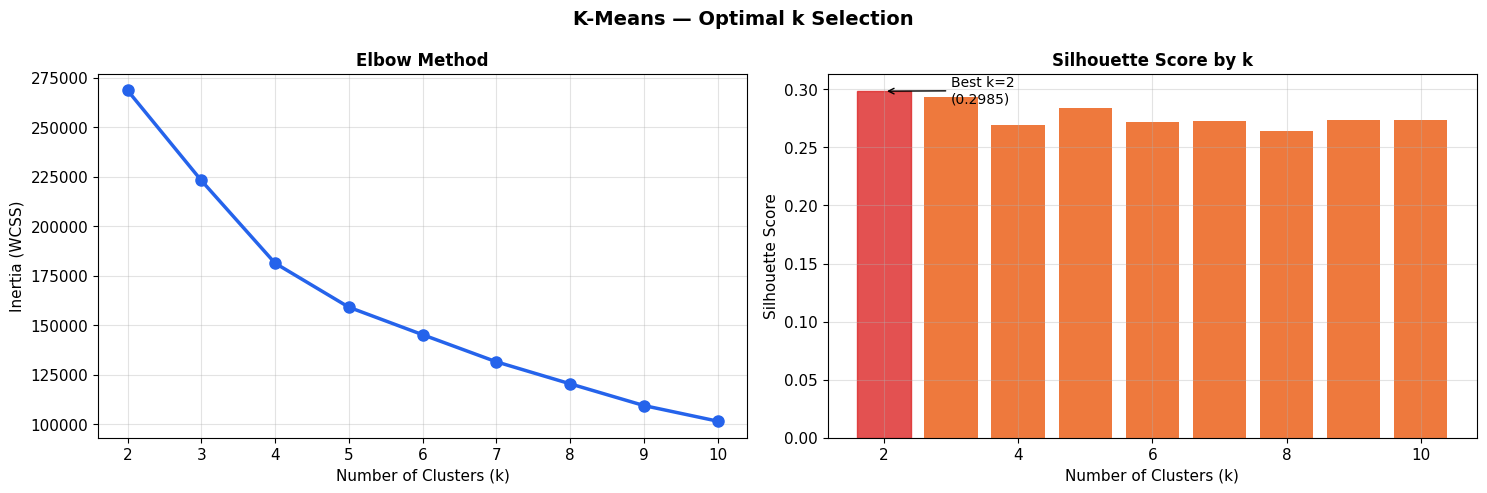

In [ ]:
# Elbow + Silhouette plot
fig, axes = plt.subplots(1, 2, figsize = (15, 5))

ax = axes[0]
ax.plot(list(K_RANGE), inertias, 'o-', color = '#2563EB', lw = 2.5, ms = 8)
ax.set_xlabel('Number of Clusters (k)', fontsize = 11)
ax.set_ylabel('Inertia (WCSS)', fontsize = 11)
ax.set_title('Elbow Method', fontweight = 'bold', fontsize = 12)

ax = axes[1]
bars = ax.bar(list(K_RANGE), sil_scores, color = '#EA580C', alpha = 0.8)
bars[np.argmax(sil_scores)].set_color('#DC2626')
ax.set_xlabel('Number of Clusters (k)', fontsize = 11)
ax.set_ylabel('Silhouette Score', fontsize = 11)
ax.set_title('Silhouette Score by k', fontweight = 'bold', fontsize = 12)
ax.annotate(f'Best k={best_k}\n({max(sil_scores):.4f})',
            xy = (best_k, max(sil_scores)),
            xytext = (best_k + 1, max(sil_scores) - 0.01),
            arrowprops = dict(arrowstyle = '->', color = 'black'),
            fontsize = 10)

plt.suptitle('K-Means - Optimal k Selection', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

In [ ]:
# Fit final K-Means with best k
km_best = KMeans(n_clusters = best_k, random_state = seed, n_init = 10)
cluster_labels = km_best.fit_predict(X_pca_k)

print(f'K-Means with k={best_k} - cluster sizes:')
for k in range(best_k):
    n = (cluster_labels == k).sum()
    pha = y_all[cluster_labels == k].mean()
    print(f'  Cluster {k+1}: {n:,} asteroids  ({100*pha:.1f}% PHA)')

K-Means with k=2 — cluster sizes:
  Cluster 1: 28,291 asteroids  (5.2% PHA)
  Cluster 2: 12,857 asteroids  (8.4% PHA)


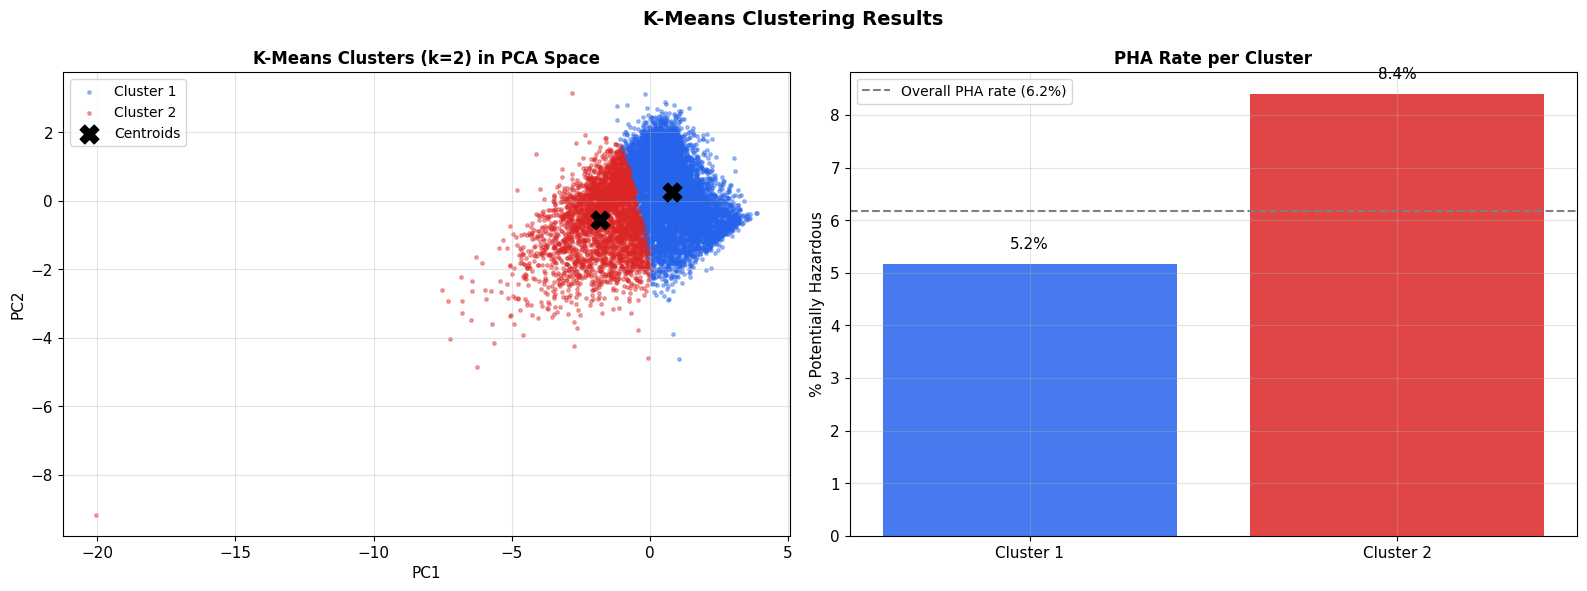

In [ ]:
# Cluster visualization in PCA space
cluster_colors = ['#2563EB', '#DC2626', '#16A34A', '#EA580C', '#7C3AED']

fig, axes = plt.subplots(1, 2, figsize = (16, 6))

ax = axes[0]
for k in range(best_k):
    mask = cluster_labels[idx_plot] == k
    ax.scatter(X_2d[idx_plot][mask, 0],
               X_2d[idx_plot][mask, 1],
               c = cluster_colors[k], s = 6, alpha = 0.4,
               label = f'Cluster {k+1}')
# Plot cluster centers projected to 2D
centers_2d = pca2d.transform(
    pca_k.inverse_transform(km_best.cluster_centers_)
)
ax.scatter(centers_2d[:,0], centers_2d[:,1],
           c = 'black', marker = 'X', s = 180, zorder = 6, label = 'Centroids')
ax.set_xlabel('PC1', fontsize = 11)
ax.set_ylabel('PC2', fontsize = 11)
ax.set_title(f'K-Means Clusters (k={best_k}) in PCA Space', fontweight = 'bold', fontsize = 12)
ax.legend(fontsize = 10)

# PHA fraction per cluster
ax = axes[1]
pha_fracs = [y_all[cluster_labels == k].mean() * 100 for k in range(best_k)]
bars = ax.bar([f'Cluster {k+1}' for k in range(best_k)],
              pha_fracs,
              color = cluster_colors[:best_k], alpha = 0.85)
ax.axhline(100 * y_all.mean(), ls = '--', color = 'gray', lw = 1.5,
           label = f'Overall PHA rate ({100 * y_all.mean():.1f}%)')
for b, v in zip(bars, pha_fracs):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.3, f'{v:.1f}%',
            ha = 'center', fontsize = 11)
ax.set_ylabel('% Potentially Hazardous', fontsize = 11)
ax.set_title('PHA Rate per Cluster', fontweight = 'bold', fontsize = 12)
ax.legend(fontsize = 10)

plt.suptitle('K-Means Clustering Results', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

In [ ]:
# Cluster profiles - mean feature values
df_clust = df[FEATURES].copy()
df_clust['cluster'] = cluster_labels
df_clust['pha'] = y_all

cluster_profile = df_clust.groupby('cluster')[FEATURES].mean().round(3)
cluster_profile.index = [f'Cluster {i+1}' for i in cluster_profile.index]

print('Cluster Feature Profiles (mean values)')
cluster_profile

--- Cluster Feature Profiles (mean values) ---


,H,e,a,i,q,ad,moid_au,n,diameter_km
Cluster 1,25.065,0.413,1.591,8.737,0.868,2.315,0.035,0.597,0.056
Cluster 2,20.722,0.481,2.122,18.665,1.017,3.227,0.186,0.384,0.409


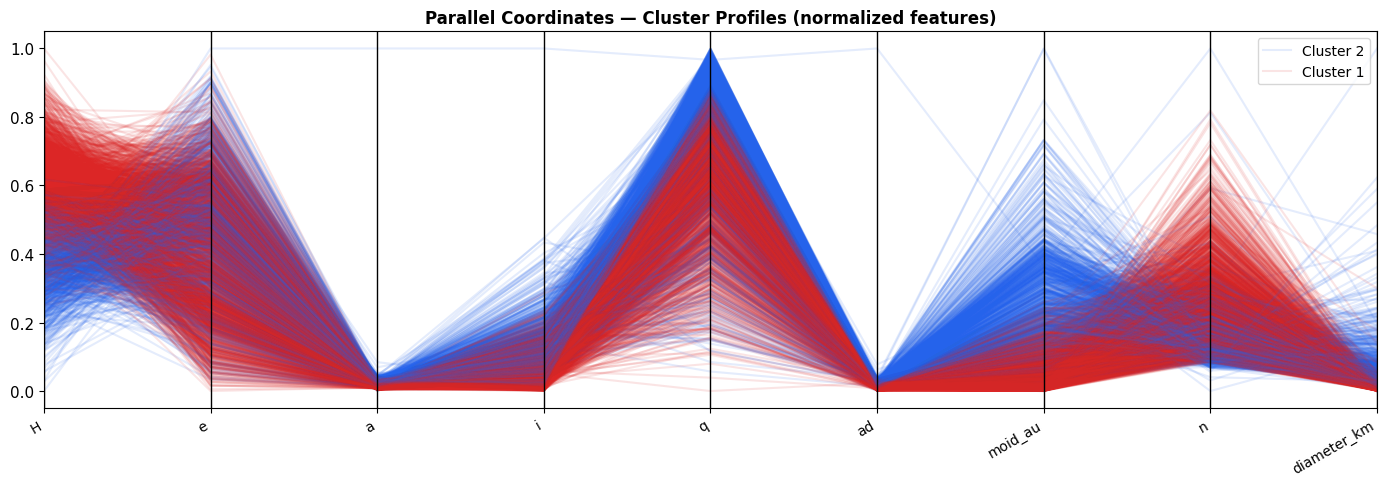

In [ ]:
# Cluster radar / parallel coordinates
from pandas.plotting import parallel_coordinates

df_para = df_clust.sample(3000, random_state = seed).copy()
df_para['cluster'] = df_para['cluster'].map(lambda k: f'Cluster {k+1}')

# Normalize for display
for f in FEATURES:
    mn, mx = df_para[f].min(), df_para[f].max()
    df_para[f] = (df_para[f] - mn) / (mx - mn + 1e-9)

fig, ax = plt.subplots(figsize = (14, 5))
parallel_coordinates(df_para[FEATURES + ['cluster']], 'cluster',
                     color = cluster_colors[:best_k], alpha = 0.12, ax = ax)
ax.set_xticklabels(FEATURES, rotation = 30, ha = 'right', fontsize = 10)
ax.set_title('Parallel Coordinates - Cluster Profiles (normalized features)',
             fontweight = 'bold', fontsize = 12)
ax.legend(fontsize = 10)
plt.tight_layout()
plt.show()

---
## 9. Results Summary

In [ ]:
# Final metrics table
print('=' * 65)
print('  SUPERVISED LEARNING - FINAL RESULTS')
print('=' * 65)
header = f"{'Model':<30} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7}"
print(header)
print('-' * 65)
for r in all_results:
    print(f"{r['name']:<30} {r['acc']:>7.4f} {r['prec']:>7.4f} "
          f"{r['rec']:>7.4f} {r['f1']:>7.4f} {r['auc']:>7.4f}")
print('=' * 65)

best_r = max(all_results, key = lambda r: r['f1'])
print(f"\nBest model by F1: {best_r['name']}")
print(f"  F1 improvement over baseline: +{best_r['f1'] - r_base['f1']:.4f}")
print(f"  AUC improvement over baseline: +{best_r['auc'] - r_base['auc']:.4f}")

print('\n' + '=' * 65)
print('  UNSUPERVISED LEARNING - FINAL RESULTS')
print('=' * 65)
print(f'  PCA: {n_95} components retain 95% of variance (from 9 original features)')
print(f'  K-Means: Best k = {best_k}  |  Silhouette = {max(sil_scores):.4f}')
print('=' * 65)

  SUPERVISED LEARNING — FINAL RESULTS
Model                              Acc    Prec     Rec      F1     AUC
-----------------------------------------------------------------
Baseline LR (C=1)               0.9772  0.8361  0.7835  0.8089  0.9916
Tuned LR (C=100)                0.9772  0.8279  0.7953  0.8112  0.9916
RBF Expansion + LR (C=100)      0.9829  0.8811  0.8360  0.8579  0.9960

Best model by F1: RBF Expansion + LR (C=100)
  F1 improvement over baseline: +0.0490
  AUC improvement over baseline: +0.0044

  UNSUPERVISED LEARNING — FINAL RESULTS
  PCA: 6 components retain 95% of variance (from 9 original features)
  K-Means: Best k = 2  |  Silhouette = 0.2985


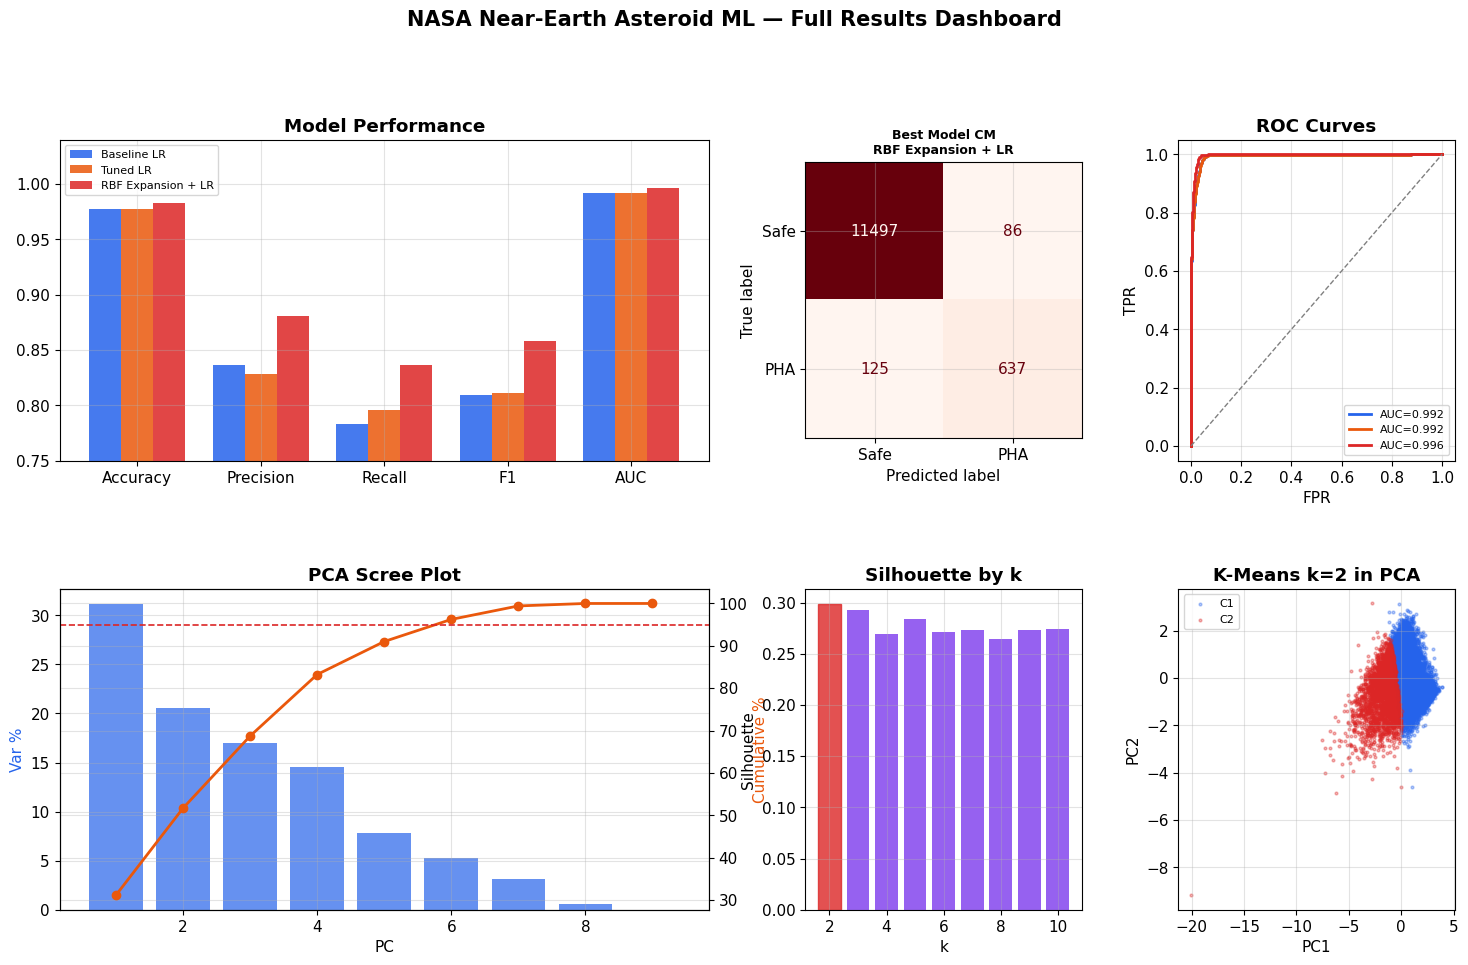

Dashboard saved as results_dashboard.png


In [ ]:
# Final combined visualization
fig = plt.figure(figsize = (18, 10))
gs = gridspec.GridSpec(2, 4, figure = fig, hspace = 0.4, wspace = 0.35)

# 1. Metric bar chart
ax1 = fig.add_subplot(gs[0, :2])
metric_keys = ['acc', 'prec', 'rec', 'f1', 'auc']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
x = np.arange(len(metric_keys))
w = 0.26
for i, (r, c) in enumerate(zip(all_results, ['#2563EB', '#EA580C', '#DC2626'])):
    vals = [r[m] for m in metric_keys]
    ax1.bar(x + (i-1) * w, vals, w, label  =r['name'].split('(')[0].strip(),
            color = c, alpha = 0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(metric_names)
ax1.set_ylim(0.75, 1.04)
ax1.set_title('Model Performance', fontweight = 'bold')
ax1.legend(fontsize = 8)

# 2. Best model CM
ax2 = fig.add_subplot(gs[0, 2])
ConfusionMatrixDisplay(best_r['cm'], display_labels = ['Safe','PHA']).plot(
    ax = ax2, cmap = 'Reds', colorbar = False)
ax2.set_title(f'Best Model CM\n{best_r["name"].split("(")[0].strip()}', fontweight = 'bold', fontsize = 9)

# 3. ROC curves
ax3 = fig.add_subplot(gs[0, 3])
for r, c in zip(all_results, ['#2563EB', '#EA580C', '#DC2626']):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax3.plot(fpr, tpr, color = c, lw = 2, label = f"AUC={r['auc']:.3f}")
ax3.plot([0,1], [0,1], '--', color = 'gray', lw = 1)
ax3.set_title('ROC Curves', fontweight = 'bold')
ax3.legend(fontsize = 8)
ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')

# 4. PCA scree
ax4 = fig.add_subplot(gs[1, :2])
ax4.bar(range(1, len(evr) + 1), evr * 100, color = '#2563EB', alpha = 0.7)
ax4r = ax4.twinx()
ax4r.plot(range(1, len(evr) + 1), cum_var * 100, 'o-', color = '#EA580C', lw = 2)
ax4r.axhline(95, ls = '--', color = '#DC2626', lw = 1.2)
ax4.set_xlabel('PC'); ax4.set_ylabel('Var %', color = '#2563EB')
ax4r.set_ylabel('Cumulative %', color = '#EA580C')
ax4.set_title('PCA Scree Plot', fontweight = 'bold')

# 5. Silhouette by k
ax5 = fig.add_subplot(gs[1, 2])
bars5 = ax5.bar(list(K_RANGE), sil_scores, color = '#7C3AED', alpha = 0.8)
bars5[np.argmax(sil_scores)].set_color('#DC2626')
ax5.set_xlabel('k'); ax5.set_ylabel('Silhouette')
ax5.set_title('Silhouette by k', fontweight = 'bold')

# 6. PCA 2D colored by cluster
ax6 = fig.add_subplot(gs[1, 3])
for k in range(best_k):
    mask = cluster_labels[idx_plot] == k
    ax6.scatter(X_2d[idx_plot][mask,0], X_2d[idx_plot][mask,1],
                c = cluster_colors[k], s = 4, alpha = 0.35, label = f'C{k+1}')
ax6.set_xlabel('PC1'); ax6.set_ylabel('PC2')
ax6.set_title(f'K-Means k={best_k} in PCA', fontweight = 'bold')
ax6.legend(fontsize = 8)

plt.suptitle('NASA Near-Earth Asteroid ML - Full Results Dashboard',
             fontsize = 15, fontweight = 'bold', y = 1.01)
plt.savefig('results_dashboard.png', dpi = 150, bbox_inches = 'tight',
            facecolor = 'white')
plt.show()
print('Dashboard saved as results_dashboard.png')